In [2]:
import pandas as pd

# Carregando os dados da nova pasta organizada
dados = pd.read_csv('dados/emp_automovel.csv')
dados


,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [3]:
x = dados.drop('inadimplente', axis=1)
y = dados['inadimplente']

In [4]:
from sklearn.tree import DecisionTreeClassifier

In [5]:
modelo = DecisionTreeClassifier()
modelo.fit(x, y)
modelo.score(x, y)

1.0

In [6]:
print(f'Acurácia: {modelo.score(x, y)}')

Acurácia: 1.0


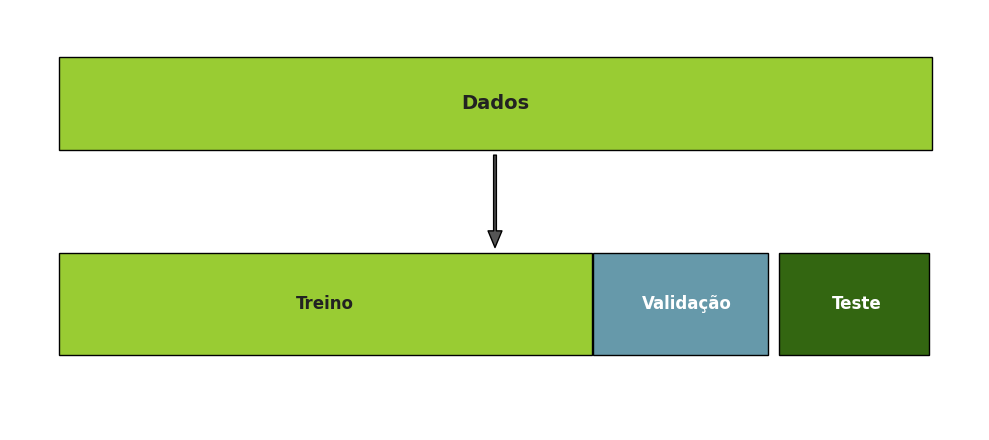

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura
fig, ax = plt.subplots(figsize=(10, 4.5))

# Estilo dos blocos (Cores)
cor_dados = '#99cc33'       
cor_treino = '#99cc33'      
cor_validacao = '#6699aa'   
cor_teste = '#336611'       

# 1. Bloco de "Dados" (Topo)
ax.add_patch(patches.Rectangle((0.5, 3.0), 9.0, 1.0, edgecolor='black', facecolor=cor_dados, lw=1))
ax.text(5.0, 3.5, 'Dados', fontsize=14, fontweight='bold', ha='center', va='center', color='#222222')

# Seta indicativa para baixo
ax.annotate('', xy=(5.0, 1.9), xytext=(5.0, 3.0),
            arrowprops=dict(facecolor='#555555', shrink=0.05, width=2, headwidth=10))

# 2. Blocos de Divisão (Base) - Com espaçamento reduzido
# Treino (Largura: 5.5)
ax.add_patch(patches.Rectangle((0.5, 0.8), 5.5, 1.1, edgecolor='black', facecolor=cor_treino, lw=1))
ax.text(3.25, 1.35, 'Treino', fontsize=12, fontweight='bold', ha='center', va='center', color='#222222')

# Validação (Começa logo após o Treino, apenas 0.08 de espaço)
ax.add_patch(patches.Rectangle((6.01, 0.8), 1.8, 1.1, edgecolor='black', facecolor=cor_validacao, lw=1))
ax.text(6.98, 1.35, 'Validação', fontsize=12, fontweight='bold', ha='center', va='center', color='white')

# Teste (Começa logo após a Validação, apenas 0.08 de espaço)
ax.add_patch(patches.Rectangle((7.93, 0.8), 1.54, 1.1, edgecolor='black', facecolor=cor_teste, lw=1))
ax.text(8.73, 1.35, 'Teste', fontsize=12, fontweight='bold', ha='center', va='center', color='white')

# Ajustes finais dos eixos
ax.set_xlim(0, 10)
ax.set_ylim(0, 4.5)
ax.axis('off')

plt.tight_layout()
plt.show()


In [8]:
from sklearn.model_selection import train_test_split


In [9]:
x, x_teste, y, y_teste = train_test_split(x, y, test_size=0.15, stratify=y, random_state=5)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify=y, random_state=5)

In [10]:
modelo = DecisionTreeClassifier()
modelo.fit(x_treino, y_treino)
print(f'Acurácia de Treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de Validação: {modelo.score(x_val, y_val)}')

Acurácia de Treino: 1.0
Acurácia de Validação: 0.846354847138751


In [11]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_treino, y_treino)
print(f'Acurácia de Treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de Validação: {modelo.score(x_val, y_val)}')

Acurácia de Treino: 0.9205574912891986
Acurácia de Validação: 0.9058444386377493


In [12]:
from sklearn.metrics import confusion_matrix


In [13]:
y_previsto = modelo.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(matriz_confusao)

[[10360   119]
 [  962    40]]


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay


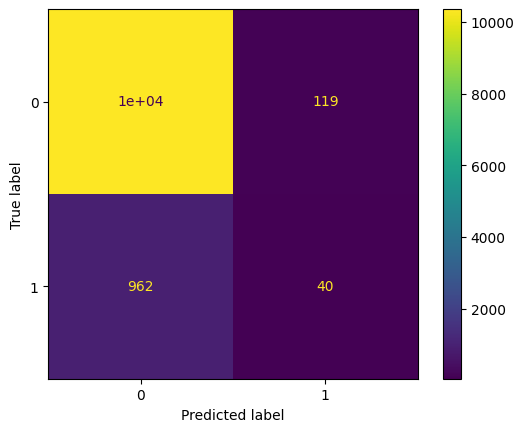

In [15]:
vizualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao)
vizualizacao.plot()

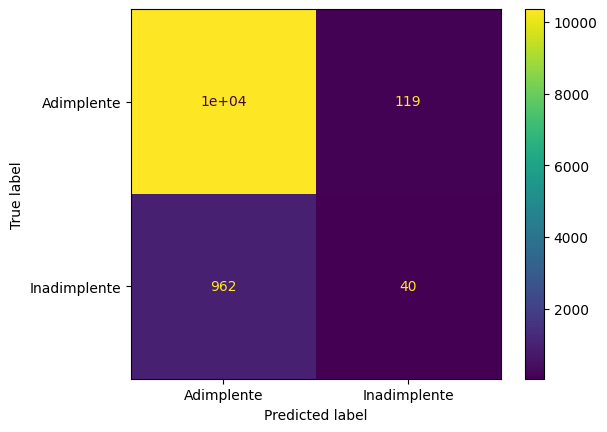

In [16]:
vizualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
vizualizacao.plot()

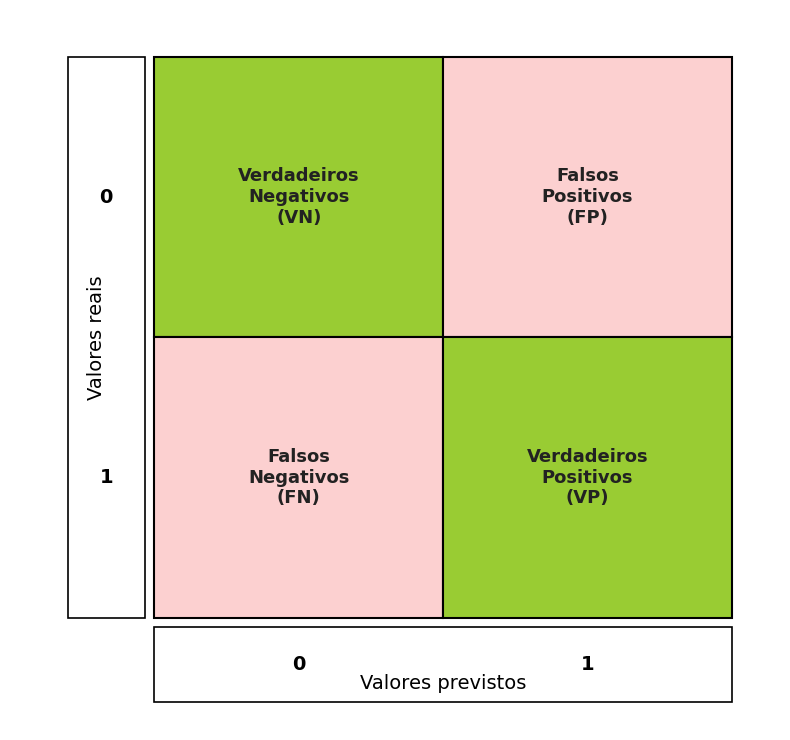

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura
fig, ax = plt.subplots(figsize=(8, 7.5))

# Cores fiéis à imagem do curso
cor_acerto = '#99cc33'     # Verde claro (Verdadeiros)
cor_erro = '#fcd0d0'       # Rosa claro (Falsos)

# 1. Desenhar os Quadrantes Principais da Matriz
# Verdadeiros Negativos (VN)
ax.add_patch(patches.Rectangle((2, 4), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(3.5, 5.5, 'Verdadeiros\nNegativos\n(VN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Positivos (FP)
ax.add_patch(patches.Rectangle((5, 4), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(6.5, 5.5, 'Falsos\nPositivos\n(FP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Negativos (FN)
ax.add_patch(patches.Rectangle((2, 1), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(3.5, 2.5, 'Falsos\nNegativos\n(FN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Verdadeiros Positivos (VP)
ax.add_patch(patches.Rectangle((5, 1), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(6.5, 2.5, 'Verdadeiros\nPositivos\n(VP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# 2. Caixa Lateral Esquerda ("Valores reais") - Fechando o retângulo completo
ax.add_patch(patches.Rectangle((1.1, 1.0), 0.8, 6.0, edgecolor='black', facecolor='none', lw=1.2))
ax.text(1.5, 5.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.5, 2.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.4, 4.0, 'Valores reais', fontsize=14, rotation=90, ha='center', va='center')

# 3. Caixa Inferior ("Valores previstos") - Fechando o retângulo completo
ax.add_patch(patches.Rectangle((2.0, 0.1), 6.0, 0.8, edgecolor='black', facecolor='none', lw=1.2))
ax.text(3.5, 0.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(6.5, 0.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(5.0, 0.3, 'Valores previstos', fontsize=14, ha='center', va='center')

# Ajustes de exibição para esconder os eixos do gráfico padrão
ax.set_xlim(0.5, 8.5)
ax.set_ylim(-0.2, 7.5)
ax.axis('off')

plt.tight_layout()
plt.show()


In [18]:
from sklearn.metrics import accuracy_score 

In [19]:
print(f'Acurácia: {accuracy_score(y_val, y_previsto)}')

Acurácia: 0.9058444386377493


In [20]:
from sklearn.metrics import precision_score, recall_score

In [21]:
print(f'Precisão: {precision_score(y_val, y_previsto)}')
print(f'Recall: {recall_score(y_val, y_previsto)}')

Precisão: 0.25157232704402516
Recall: 0.03992015968063872


In [24]:
from sklearn.metrics import f1_score

In [25]:
print(f'F1-Score: {f1_score(y_val, y_previsto)}')

F1-Score: 0.06890611541774333


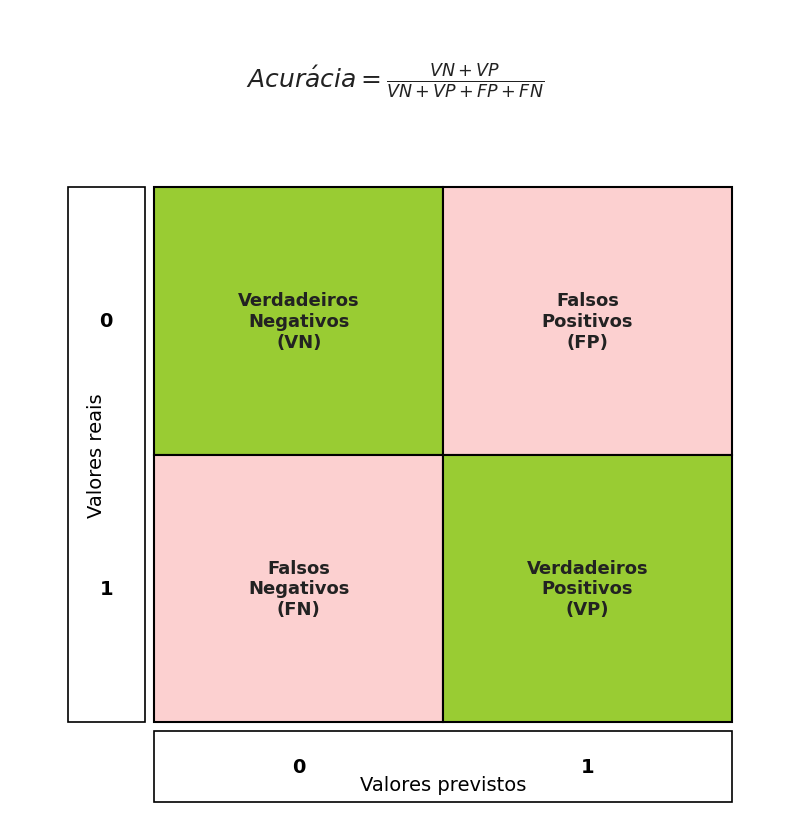

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura (aumentada na altura para caber a fórmula)
fig, ax = plt.subplots(figsize=(8, 8.5))

# Fórmula Matemática no Topo (usando sintaxe LaTeX nativa do Matplotlib)
ax.text(4.5, 8.2, r'$Acur\acute{a}cia = \frac{VN + VP}{VN + VP + FP + FN}$', 
        fontsize=18, fontweight='bold', ha='center', va='center', color='#222222')

# Cores fiéis à imagem do curso
cor_acerto = '#99cc33'     # Verde claro (Verdadeiros)
cor_erro = '#fcd0d0'       # Rosa claro (Falsos)

# 1. Desenhar os Quadrantes Principais da Matriz
# Verdadeiros Negativos (VN)
ax.add_patch(patches.Rectangle((2, 4), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(3.5, 5.5, 'Verdadeiros\nNegativos\n(VN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Positivos (FP)
ax.add_patch(patches.Rectangle((5, 4), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(6.5, 5.5, 'Falsos\nPositivos\n(FP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Negativos (FN)
ax.add_patch(patches.Rectangle((2, 1), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(3.5, 2.5, 'Falsos\nNegativos\n(FN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Verdadeiros Positivos (VP)
ax.add_patch(patches.Rectangle((5, 1), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(6.5, 2.5, 'Verdadeiros\nPositivos\n(VP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# 2. Caixa Lateral Esquerda ("Valores reais")
ax.add_patch(patches.Rectangle((1.1, 1.0), 0.8, 6.0, edgecolor='black', facecolor='none', lw=1.2))
ax.text(1.5, 5.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.5, 2.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.4, 4.0, 'Valores reais', fontsize=14, rotation=90, ha='center', va='center')

# 3. Caixa Inferior ("Valores previstos")
ax.add_patch(patches.Rectangle((2.0, 0.1), 6.0, 0.8, edgecolor='black', facecolor='none', lw=1.2))
ax.text(3.5, 0.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(6.5, 0.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(5.0, 0.3, 'Valores previstos', fontsize=14, ha='center', va='center')

# Ajustes de exibição para esconder os eixos do gráfico padrão
ax.set_xlim(0.5, 8.5)
ax.set_ylim(-0.2, 9.0)
ax.axis('off')

plt.tight_layout()
plt.show()


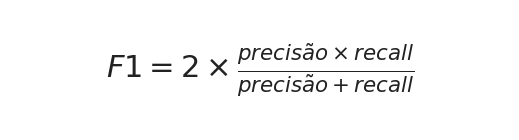

In [32]:
import matplotlib.pyplot as plt

# 1. Diminuímos o tamanho da figura (de 6x2.5 para 5x1.2) para cortar o excesso de branco
fig, ax = plt.subplots(figsize=(5, 1.2))

fórmula_f1 = r'$F1 = 2 \times \frac{precis\tilde{a}o \times recall}{precis\tilde{a}o + recall}$'

# 2. Centralizamos o texto usando coordenadas fixas
ax.text(0.5, 0.5, fórmula_f1, fontsize=22, ha='center', va='center', color='#222222')

# 3. Travamos os limites bem justos para eliminar as margens invisíveis
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# O pad=0 remove qualquer margem restante nas bordas externas
plt.tight_layout(pad=0)
plt.show()


Curva ROC

In [33]:
from sklearn.metrics import RocCurveDisplay

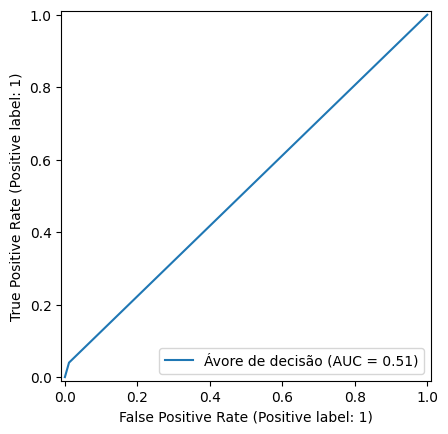

In [34]:
RocCurveDisplay.from_predictions(y_val, y_previsto, name='Ávore de decisão');

In [35]:
from sklearn.metrics import roc_auc_score

In [36]:
print(f'AUC: {roc_auc_score(y_val, y_previsto)}')

AUC: 0.5142820571282285


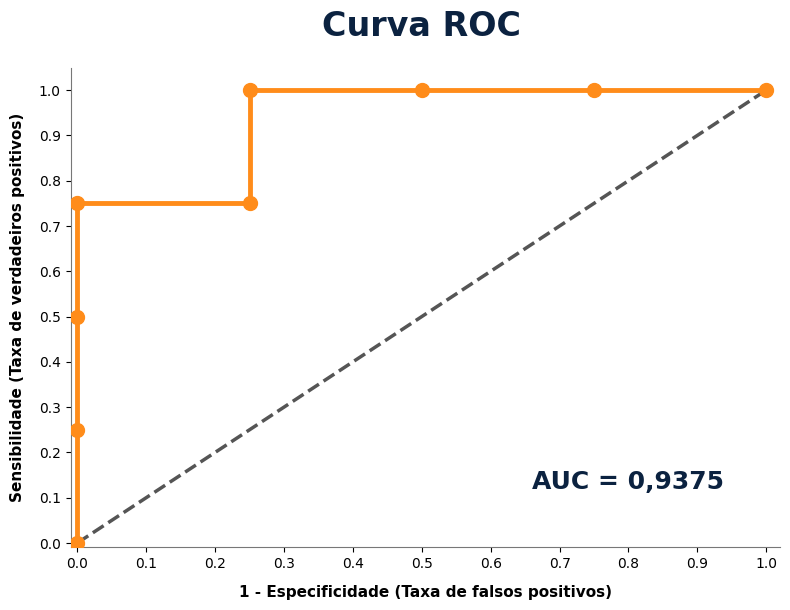

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuração da figura com bordas limpas
fig, ax = plt.subplots(figsize=(8, 6.2))

# 2. Definição dos pontos da curva (Extraídos do gráfico)
x_pontos = [0, 0, 0, 0, 0.25, 0.25, 0.5, 0.75, 1]
y_pontos = [0, 0.25, 0.5, 0.75, 0.75, 1, 1, 1, 1]

# 3. Plotagem das linhas e elementos visuais
# Linha pontilhada diagonal de referência (cinza escuro)
ax.plot([0, 1], [0, 1], color='#555555', linestyle='--', linewidth=2.5)

# Curva ROC principal (linha laranja contínua)
ax.plot(x_pontos, y_pontos, color='#ff8c1a', linewidth=3.5, zorder=2)

# Marcadores redondos nos vértices dos pontos (laranja)
ax.scatter(x_pontos, y_pontos, color='#ff8c1a', s=100, zorder=3)

# 4. Título e Textos Informativos (Centralizados)
# Mudamos o X para 0.5 e o alinhamento horizontal (ha) para 'center'
ax.text(0.5, 1.12, 'Curva ROC', fontsize=24, fontweight='bold', color='#0b2240', ha='center')

# O texto da AUC foi levemente reajustado para ficar centralizado no canto inferior direito
ax.text(0.80, 0.12, 'AUC = 0,9375', fontsize=18, fontweight='bold', color='#0b2240', ha='center')

# 5. Configuração detalhada dos Eixos
ax.set_xlabel('1 - Especificidade (Taxa de falsos positivos)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Sensibilidade (Taxa de verdadeiros positivos)', fontsize=11, fontweight='bold', labelpad=10)

# Valores fixos dos eixos de 0 a 1 (passo de 0,1)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))

# Ajuste fino dos limites para colar o gráfico nas bordas e sumir com espaços vazios
ax.set_xlim(-0.01, 1.02)
ax.set_ylim(-0.01, 1.05)

# Remove as bordas superior e direita do gráfico para o estilo limpo do slide
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#777777')
ax.spines['bottom'].set_color('#777777')

plt.tight_layout()
plt.show()


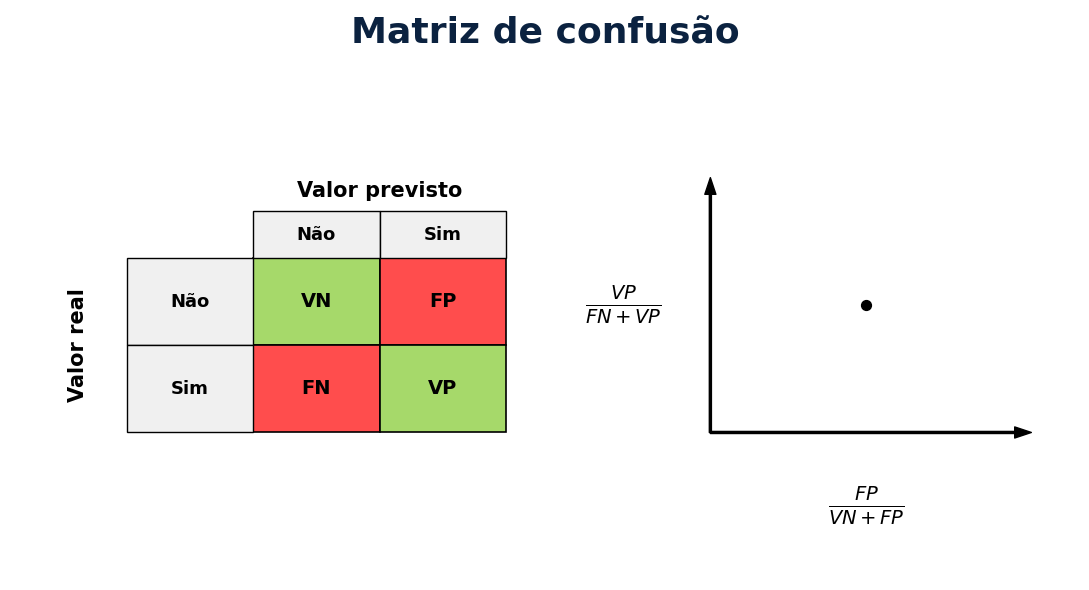

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura (tamanho horizontal expandido para caber os dois lados)
fig, ax = plt.subplots(figsize=(11, 6))

# Cores oficiais atualizadas
cor_acerto = '#a6d96a'     # Verde claro (VN / VP)
cor_erro = '#ff4d4d'       # Vermelho vivo (FP / FN)
cor_titulo = '#0b2240'     # Azul escuro

# Título Principal (Centralizado no topo do gráfico inteiro)
ax.text(5.5, 9.0, 'Matriz de confusão', fontsize=26, fontweight='bold', color=cor_titulo, ha='center')

# =========================================================================
# LADO ESQUERDO: MATRIZ DE CONFUSÃO (ALINHADA E CENTRALIZADA)
# =========================================================================

# Quadrantes Principais
# VN (Verde)
ax.add_patch(patches.Rectangle((2.5, 4.5), 1.3, 1.3, edgecolor='black', facecolor=cor_acerto, lw=1.2))
ax.text(3.15, 5.15, 'VN', fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# FP (Vermelho com letra Preta)
ax.add_patch(patches.Rectangle((3.8, 4.5), 1.3, 1.3, edgecolor='black', facecolor=cor_erro, lw=1.2))
ax.text(4.45, 5.15, 'FP', fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# FN (Vermelho com letra Preta)
ax.add_patch(patches.Rectangle((2.5, 3.2), 1.3, 1.3, edgecolor='black', facecolor=cor_erro, lw=1.2))
ax.text(3.15, 3.85, 'FN', fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# VP (Verde)
ax.add_patch(patches.Rectangle((3.8, 3.2), 1.3, 1.3, edgecolor='black', facecolor=cor_acerto, lw=1.2))
ax.text(4.45, 3.85, 'VP', fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# Rótulos de "Não" e "Sim"
# Colunas (Valor previsto)
ax.add_patch(patches.Rectangle((2.5, 5.8), 1.3, 0.7, edgecolor='black', facecolor='#f0f0f0', lw=1))
ax.text(3.15, 6.15, 'Não', fontsize=13, fontweight='bold', ha='center', va='center')

ax.add_patch(patches.Rectangle((3.8, 5.8), 1.3, 0.7, edgecolor='black', facecolor='#f0f0f0', lw=1))
ax.text(4.45, 6.15, 'Sim', fontsize=13, fontweight='bold', ha='center', va='center')

# Linhas (Valor real)
ax.add_patch(patches.Rectangle((1.2, 4.5), 1.3, 1.3, edgecolor='black', facecolor='#f0f0f0', lw=1))
ax.text(1.85, 5.15, 'Não', fontsize=13, fontweight='bold', ha='center', va='center')

ax.add_patch(patches.Rectangle((1.2, 3.2), 1.3, 1.3, edgecolor='black', facecolor='#f0f0f0', lw=1))
ax.text(1.85, 3.85, 'Sim', fontsize=13, fontweight='bold', ha='center', va='center')

# TEXTOS INDICADORES TOTALMENTE CENTRALIZADOS:
ax.text(3.8, 6.8, 'Valor previsto', fontsize=15, fontweight='bold', ha='center', va='center')
ax.text(0.7, 4.5, 'Valor real', fontsize=15, fontweight='bold', rotation=90, ha='center', va='center')

# =========================================================================
# LADO DIREITO: GRÁFICO CARTESIANO COM AS FÓRMULAS
# =========================================================================

# Desenho das Setas dos Eixos (X e Y)
ax.annotate('', xy=(7.2, 7.0), xytext=(7.2, 3.2), arrowprops=dict(facecolor='black', width=1.5, headwidth=8, shrink=0))
ax.annotate('', xy=(10.5, 3.2), xytext=(7.2, 3.2), arrowprops=dict(facecolor='black', width=1.5, headwidth=8, shrink=0))

# Ponto cartesiano isolado no meio do gráfico
ax.scatter([8.8], [5.1], color='black', s=50, zorder=5)

# Fórmula Matemática do Eixo Y
ax.text(6.3, 5.1, r'$\frac{VP}{FN + VP}$', fontsize=20, ha='center', va='center')

# Fórmula Matemática do Eixo X
ax.text(8.8, 2.1, r'$\frac{FP}{VN + FP}$', fontsize=20, ha='center', va='center')

# =========================================================================
# CONFIGURAÇÕES FINAIS DE BORDA E EXIBIÇÃO
# =========================================================================
ax.set_xlim(0, 11)
ax.set_ylim(1, 9.5)
ax.axis('off')

plt.tight_layout()
plt.show()
